# 🤖 Entrenamiento de Modelos Baseline — `IsToxic`

## 🎯 Objetivo
Entrenar y evaluar dos modelos baseline de clasificación binaria sobre `IsToxic`,
con tracking completo de experimentos en MLflow/DagsHub.

## 📋 Flujo
1. Conexión con DagsHub + MLflow
2. Carga de datos preprocesados
3. Vectorización TF-IDF
4. Funciones auxiliares de evaluación
5. Logistic Regression
6. LightGBM
7. Comparativa final

> Los CSVs de entrada vienen de `data/processed/V_04/` generados en el notebook
> de preprocesamiento. La vectorización TF-IDF se hace aquí para poder loguear
> sus parámetros en MLflow.

In [5]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
import dagshub

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay
)
from lightgbm import LGBMClassifier

warnings.filterwarnings('ignore')

TARGET       = 'IsToxic'
RANDOM_STATE = 42
AVG_METHOD   = 'binary'

os.makedirs('../../reports/figures', exist_ok=True)
os.makedirs('../../models', exist_ok=True)

print('Setup completado.')

Setup completado.


## 🔗 1. Conexión con DagsHub y MLflow

> ⚠️ Ejecutar esta celda cada vez que se reinicie el kernel o se quiera
> loguear un nuevo experimento. El servidor de DagsHub no mantiene la
> conexión indefinidamente.

In [28]:
# ── CELDA 1 ──────────────────────────────────────────────────────────────────
import os
import dagshub
import mlflow

# FIX: timeout mayor para conexiones lentas
os.environ['MLFLOW_HTTP_REQUEST_TIMEOUT'] = '120'

# Cerrar cualquier run que haya quedado abierto
mlflow.end_run()

token = "f16c39c4380542f071674b19fac461d44195b694"
os.environ["MLFLOW_TRACKING_USERNAME"] = "RaulCtm"
os.environ["MLFLOW_TRACKING_PASSWORD"] = token

dagshub.init(
    repo_owner='gemita284',
    repo_name='Project_9_NLP_Team2',
    mlflow=True
)

mlflow.set_experiment('youtube_toxic_comments')

print(f'✅ Conexión establecida')
print(f'   Tracking URI: {mlflow.get_tracking_uri()}')
print(f'   Experimento : youtube_toxic_comments')
print(f'\n   https://dagshub.com/gemita284/Project_9_NLP_Team2.mlflow')

Initialized MLflow to track repo "gemita284/Project_9_NLP_Team2"

Repository gemita284/Project_9_NLP_Team2 initialized!

✅ Conexión establecida
   Tracking URI: https://dagshub.com/gemita284/Project_9_NLP_Team2.mlflow
   Experimento : youtube_toxic_comments

   https://dagshub.com/gemita284/Project_9_NLP_Team2.mlflow


## 📂 2. Carga de datos preprocesados

Se cargan los tres conjuntos generados en el notebook de preprocesamiento.
`test.csv` se carga aquí pero **no se usa hasta la evaluación final**.

In [6]:
# ── CELDA 2 ──────────────────────────────────────────────────────────────────
# commit: "feat: load preprocessed train/val/test splits from data/processed/V_04 (#15, #11)"
train_df = pd.read_csv('../../data/processed/V_04/train_augmented.csv')
val_df   = pd.read_csv('../../data/processed/V_04/val.csv')
test_df  = pd.read_csv('../../data/processed/V_04/test.csv')

print('Conjuntos cargados:')
print(f'  Train : {len(train_df):>4} filas  |  tóxico: {train_df[TARGET].mean():.1%}')
print(f'  Val   : {len(val_df):>4} filas  |  tóxico: {val_df[TARGET].mean():.1%}')
print(f'  Test  : {len(test_df):>4} filas  |  tóxico: {test_df[TARGET].mean():.1%}')

X_train_raw = train_df['text_procesado']
X_val_raw   = val_df['text_procesado']
X_test_raw  = test_df['text_procesado']

y_train = train_df[TARGET].astype(int)
y_val   = val_df[TARGET].astype(int)
y_test  = test_df[TARGET].astype(int)

Conjuntos cargados:
  Train :  741 filas  |  tóxico: 46.6%
  Val   :  150 filas  |  tóxico: 46.0%
  Test  :  150 filas  |  tóxico: 46.0%


## 🔢 3. Vectorización TF-IDF

El vectorizador se ajusta **solo sobre train** y se aplica con `transform`
sobre val y test, simulando el comportamiento real en producción.

Los parámetros se loguearán en cada run de MLflow junto con los del modelo.

| Parámetro | Valor |
|---|---|
| `max_features` | 5 000 |
| `ngram_range` | (1, 2) |
| `min_df` | 2 |
| `max_df` | 0.95 |
| `sublinear_tf` | True |

In [8]:
# ── CELDA 3 ──────────────────────────────────────────────────────────────────
# commit: "feat: fit TF-IDF on train and transform val/test, ready for MLflow logging (#15, #11)"
TFIDF_PARAMS = {
    'max_features': 5000,
    'ngram_range':  (1, 2),
    'min_df':       2,
    'max_df':       0.95,
    'sublinear_tf': True
}

vectorizer = TfidfVectorizer(**TFIDF_PARAMS)

X_train = vectorizer.fit_transform(X_train_raw)
X_val   = vectorizer.transform(X_val_raw)
X_test  = vectorizer.transform(X_test_raw)

print('Dimensiones TF-IDF:')
print(f'  Train: {X_train.shape}')
print(f'  Val  : {X_val.shape}')
print(f'  Test : {X_test.shape}')

# Guardar vectorizador
import joblib
joblib.dump(vectorizer, '../../models/tfidf_vectorizer_IsToxic_V04.pkl')
print('\nVectorizador guardado en models/')

Dimensiones TF-IDF:
  Train: (741, 1998)
  Val  : (150, 1998)
  Test : (150, 1998)

Vectorizador guardado en models/


## 🛠️ 4. Funciones auxiliares de evaluación

Se definen dos funciones reutilizables para ambos modelos:
- `get_metrics`: calcula todas las métricas estandarizadas del equipo
- `save_confusion_matrix`: genera y guarda la matriz de confusión como imagen
  para subirla como artefacto a MLflow

In [9]:
def get_metrics(model, X_train, y_train, X_test, y_test):
    y_pred_train = model.predict(X_train)
    y_pred_test  = model.predict(X_test)
    y_proba_test = model.predict_proba(X_test)[:, 1]

    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test  = accuracy_score(y_test,  y_pred_test)
    f1_train  = f1_score(y_train, y_pred_train, average=AVG_METHOD)
    f1_test   = f1_score(y_test,  y_pred_test,  average=AVG_METHOD)

    return {
        'acc_train':        acc_train,
        'acc_test':         acc_test,
        'f1_train':         f1_train,
        'f1_test':          f1_test,
        'y_pred_test':      y_pred_test,
        'y_proba_test':     y_proba_test,
    }


def save_confusion_matrix(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    cm     = confusion_matrix(y_test, y_pred)

    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(cm, display_labels=['No tóxico', 'Tóxico']).plot(
        ax=ax, colorbar=False, cmap='Blues'
    )
    ax.set_title(f'Matriz de confusión — {model_name}')
    plt.tight_layout()

    ruta = f'../../reports/figures/cm_{model_name.lower().replace(" ", "_")}V04.png'
    plt.savefig(ruta, dpi=150)
    plt.show()
    return ruta


print('Funciones auxiliares listas.')

Funciones auxiliares listas.


## 📈 5. Logistic Regression — Baseline

Modelo lineal rápido e interpretable. Muy competitivo con TF-IDF en texto disperso.
Se usa `class_weight='balanced'` para compensar cualquier desbalance residual.

Los resultados y artefactos se loguan en MLflow bajo el run `LogisticRegression_baseline`.

  ENTRENANDO LOGISTIC REGRESSION


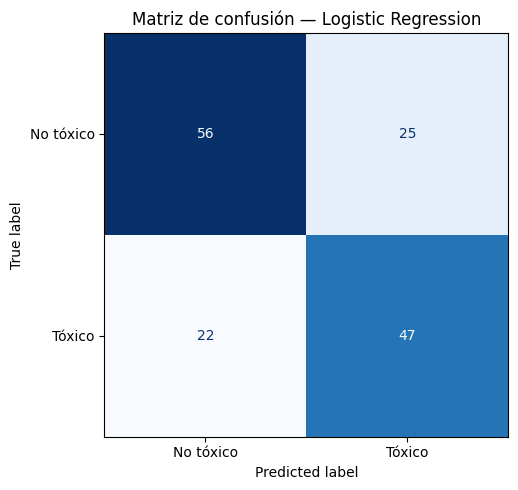


accuracy_train : 0.9406
accuracy_test  : 0.6867
f1_train       : 0.9366
f1_test        : 0.6667
overfitting_f1 : 0.2699

  REGISTRANDO LOGISTIC REGRESSION EN MLFLOW


2026/05/13 23:23:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/13 23:23:49 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/13 23:23:53 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run LogisticRegression_baseline at: https://dagshub.com/gemita284/Project_9_NLP_Team2.mlflow/#/experiments/0/runs/02a35ceda6b1495d9169a28749168aca
🧪 View experiment at: https://dagshub.com/gemita284/Project_9_NLP_Team2.mlflow/#/experiments/0

✅ Métricas registradas
✅ Matriz de confusión subida como artefacto
✅ Modelo guardado

   https://dagshub.com/gemita284/Project_9_NLP_Team2.mlflow


In [29]:
LR_PARAMS = {
    'C':            1.0,
    'penalty':      'l2',
    'solver':       'saga',
    'max_iter':     1000,
    'class_weight': 'balanced',
    'random_state': RANDOM_STATE
}

print('=' * 60)
print('  ENTRENANDO LOGISTIC REGRESSION')
print('=' * 60)

lr_model = LogisticRegression(**LR_PARAMS)
lr_model.fit(X_train, y_train)

m          = get_metrics(lr_model, X_train, y_train, X_test, y_test)
ruta_cm_lr = save_confusion_matrix(lr_model, X_test, y_test, 'Logistic Regression')

print(f'\naccuracy_train : {m["acc_train"]:.4f}')
print(f'accuracy_test  : {m["acc_test"]:.4f}')
print(f'f1_train       : {m["f1_train"]:.4f}')
print(f'f1_test        : {m["f1_test"]:.4f}')
print(f'overfitting_f1 : {m["f1_train"] - m["f1_test"]:.4f}')

# ── MLflow ────────────────────────────────────────────────────────────────────
print('\n' + '=' * 60)
print('  REGISTRANDO LOGISTIC REGRESSION EN MLFLOW')
print('=' * 60)

with mlflow.start_run(run_name='LogisticRegression_baseline'):

    mlflow.log_param('modelo',        'LogisticRegression')
    mlflow.log_param('C',             LR_PARAMS['C'])
    mlflow.log_param('penalty',       LR_PARAMS['penalty'])
    mlflow.log_param('solver',        LR_PARAMS['solver'])
    mlflow.log_param('max_iter',      LR_PARAMS['max_iter'])
    mlflow.log_param('class_weight',  LR_PARAMS['class_weight'])

    mlflow.log_param('vectorizer',   'TF-IDF')
    mlflow.log_param('max_features', TFIDF_PARAMS['max_features'])
    mlflow.log_param('ngram_range',  str(TFIDF_PARAMS['ngram_range']))
    mlflow.log_param('min_df',       TFIDF_PARAMS['min_df'])
    mlflow.log_param('max_df',       TFIDF_PARAMS['max_df'])

    mlflow.log_metrics({
        'accuracy_train':  m['acc_train'],
        'accuracy_test':   m['acc_test'],
        'f1_train':        m['f1_train'],
        'f1_test':         m['f1_test'],
        'precision_test':  precision_score(y_test, m['y_pred_test'],  average=AVG_METHOD),
        'recall_test':     recall_score(y_test,    m['y_pred_test'],  average=AVG_METHOD),
        'roc_auc_test':    roc_auc_score(y_test,   m['y_proba_test']),
        'overfitting_acc': m['acc_train'] - m['acc_test'],
        'overfitting_f1':  m['f1_train']  - m['f1_test'],
    })

    mlflow.set_tag('developer',  'Raul')
    mlflow.set_tag('model_type', 'baseline')
    mlflow.set_tag('vectorizer', 'TF-IDF')

    mlflow.log_artifact(ruta_cm_lr)
    mlflow.sklearn.log_model(lr_model, 'logistic_regression_model')
    mlflow.end_run()  

print('\n✅ Métricas registradas')
print('✅ Matriz de confusión subida como artefacto')
print('✅ Modelo guardado')
print('\n   https://dagshub.com/gemita284/Project_9_NLP_Team2.mlflow')